In [3]:
# ============================================================
# CONFIGURACIÓN DE ENTORNO
# ============================================================
ENTORNO      = "colab" # Opciones: "local" o "colab"
ALMACENAMIENTO = "drive" # Opciones: "local" o "drive" (solo aplica si ENTORNO = "colab")

# Rutas base según la configuración
RUTA_DRIVE = '/content/drive/MyDrive/TFM'

import os
import sys

# Ajuste automático: si el CWD ya es MACE/, sube un nivel al raíz del proyecto
RUTA_LOCAL = '..' if os.path.basename(os.getcwd()) == 'MACE' else '.'

if ENTORNO == "colab":
    print("Ejecutando en entorno Google Colab...")
    if ALMACENAMIENTO == "drive":
        from google.colab import drive
        drive.mount('/content/drive')
        print(f"Drive montado.")

    # Instalar dependencias ANTES de cambiar el directorio (evita error FUSE de Drive)
    print("Instalando dependencias...")
    import subprocess
    req_path = os.path.join(RUTA_DRIVE, 'requirements.txt') if ALMACENAMIENTO == "drive" else 'requirements.txt'
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", req_path], cwd="/content")

    # Cambiar al directorio del proyecto DESPUÉS de instalar
    if ALMACENAMIENTO == "drive":
        os.chdir(RUTA_DRIVE)
    print(f"Directorio de trabajo: {os.getcwd()}")

elif ENTORNO == "local":
    os.chdir(RUTA_LOCAL)
    print(f"Ejecutando en entorno local. Directorio actual: {os.getcwd()}")
    if 'google.colab' in sys.modules:
        print("ADVERTENCIA: Parece que estás en Colab pero has seleccionado entorno 'local'.")
else:
    print("Entorno no reconocido. Usa 'colab' o 'local'.")

# Verificar que la librería de convergencia es accesible
assert os.path.exists('libraries/convergence.py'), \
    f"No se encuentra libraries/convergence.py desde {os.getcwd()}. Revisa RUTA_LOCAL / RUTA_DRIVE."
print("Librería de convergencia encontrada. ✓")

Ejecutando en entorno Google Colab...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive montado.
Instalando dependencias...
Directorio de trabajo: /content/drive/MyDrive/TFM
Librería de convergencia encontrada. ✓


In [ ]:
%load_ext autoreload
%autoreload 2

In [4]:
# ============================================================
# PARÁMETROS DE ANÁLISIS
# ============================================================
# Nombre del material a analizar (debe coincidir con la carpeta en MACE/results/)
MATERIAL = "BaLiF3"

# Frames de equilibración a descartar antes del análisis de producción.
# - Para runs cortas de test (p.ej. 5000 pasos): usa 0
# - Para runs de producción largas (p.ej. 50000 pasos): usa ~500
STEP_EQUIV = 0   # <-- pon 0 para test, ~500 para producción

# Stride de lectura de frames (1 = todos, 2 = uno de cada dos, etc.)
STEP_SKIP = 2

# Ruta a los resultados del material
# Los resultados de npt.py se guardan en MACE/results/<MATERIAL>/
md_path  = os.path.join('MACE', 'results', MATERIAL)
filename = f'{MATERIAL}.traj'

assert os.path.exists(md_path), (
    f"No se encuentra la carpeta de resultados: {md_path}\n"
    f"Asegúrate de haber ejecutado run-MACE.ipynb para este material primero."
)
assert os.path.exists(os.path.join(md_path, filename)), (
    f"No se encuentra el fichero de trayectoria: {os.path.join(md_path, filename)}\n"
    f"La simulación puede no haber completado correctamente."
)

print(f"Analizando: {MATERIAL}")
print(f"  Directorio : {os.path.abspath(md_path)}")
print(f"  Trayectoria: {filename}")
print(f"  step_equiv : {STEP_EQUIV} ({'sin skip de equilibración' if STEP_EQUIV == 0 else 'frames de equilibración descartados'})")
print(f"  step_skip  : {STEP_SKIP}")

Analizando: BaLiF3
  Directorio : /content/drive/MyDrive/TFM/MACE/results/BaLiF3
  Trayectoria: BaLiF3.traj
  step_equiv : 0 (sin skip de equilibración)
  step_skip  : 2


Starting analysis for MACE/results/BaLiF3/BaLiF3.traj...

Analyzing convergence (T, P, V)...

Loading trajectory}...
Loaded 251 frames (stride=2).
Removed 0 equilibration steps.
Equilibration: 0.00 ps, production: 0.50 ps, effective timestep: 2 fs.
No equilibration phase (step_equiv=0). All frames used as production.


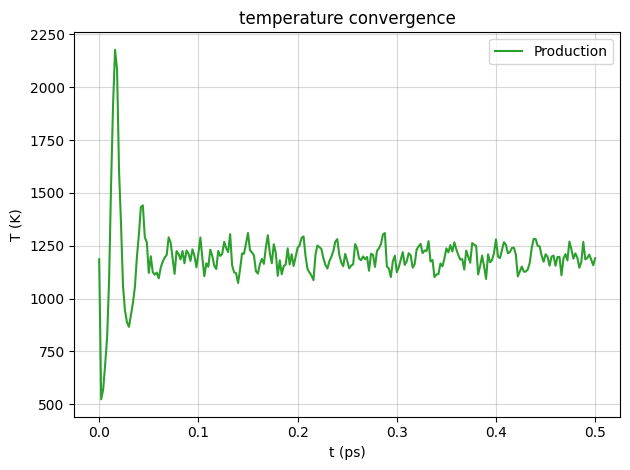

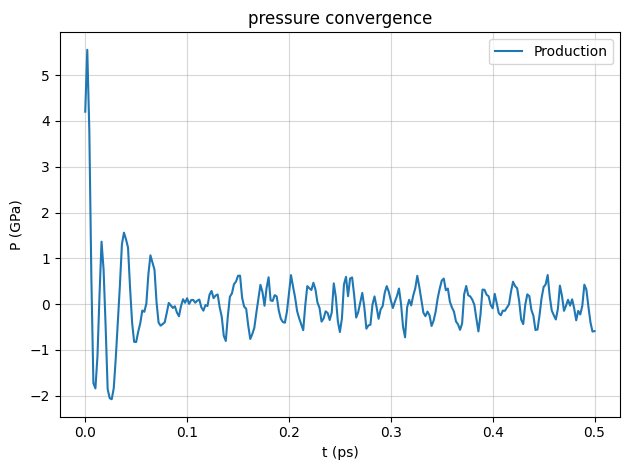

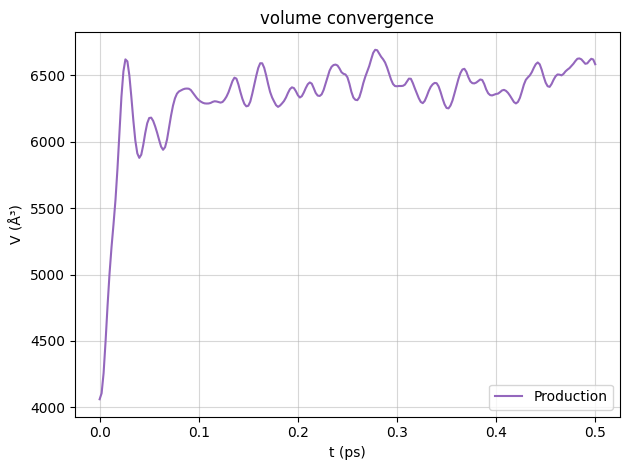


Analyzing diffusion...
Detected species: ['Ba', 'F', 'Li']
  > Processing Ba...
	Error analyzing Ba: Not enough data to calculate diffusivity
  > Processing F...
	Error analyzing F: Not enough data to calculate diffusivity
  > Processing Li...
	Error analyzing Li: Not enough data to calculate diffusivity


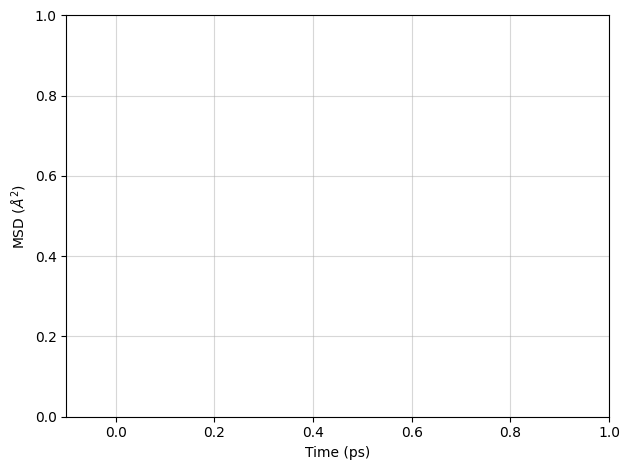


Saving results...
Results saved to MACE/results/BaLiF3/npt-convergence.json
----------------------------------------
Summary (stats calculated on production frames only)
T (K):   1196.00 +/- 140.86
P (GPa): 0.02 +/- 0.71
V (A^3): 6336.71 +/- 354.53
Diffusion:
----------------------------------------


In [5]:
if '.' not in sys.path:
    sys.path.insert(0, '.')

import libraries.convergence as con

con.analyze_convergence_and_diffusion(
    md_path=md_path,
    filename=filename,
    step_skip=STEP_SKIP,
    step_equiv=STEP_EQUIV
)